#  Notebook 1 — Data Exploration
## medical-o1-reasoning-SFT Dataset Analysis

**Purpose:** Understand the dataset before training.
- Sample structure and quality
- Length distributions (question / CoT / answer)
- Medical topic coverage
- Chat-template preview

**No GPU required.** Run on CPU or any Colab instance.

## Cell 1 — Install Dependencies

In [1]:
# Only needed if running standalone (not from the cloned repo)
!pip install datasets transformers tokenizers rich tqdm -q
print("✓ Dependencies ready")

✓ Dependencies ready



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — Load the Raw Dataset

In [3]:
from datasets import load_dataset

DATASET_NAME = "FreedomIntelligence/medical-o1-reasoning-SFT"
NUM_SAMPLES   = 5_000   # subset we'll use for training
SEED          = 42

print(f"Loading {DATASET_NAME}...")
full_ds = load_dataset(DATASET_NAME, "en",split="train")
print(f"Full dataset: {len(full_ds):,} samples")
print(f"Columns     : {full_ds.column_names}")
print(f"\nFirst row keys: {list(full_ds[0].keys())}")

Loading FreedomIntelligence/medical-o1-reasoning-SFT...


medical_o1_sft.json:   0%|          | 0.00/58.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19704 [00:00<?, ? examples/s]

Full dataset: 19,704 samples
Columns     : ['Question', 'Complex_CoT', 'Response']

First row keys: ['Question', 'Complex_CoT', 'Response']


## Cell 3 — Sample Viewer

In [4]:
import textwrap

def show_sample(idx: int):
    row = full_ds[idx]
    sep = "─" * 80
    print(f"\n{sep}")
    print(f"SAMPLE #{idx}")
    print(sep)
    print("\n[QUESTION]")
    print(textwrap.fill(row["Question"], width=80))
    print("\n[REASONING CHAIN (first 800 chars)]")
    print(row["Complex_CoT"][:800])
    print("\n[FINAL ANSWER]")
    print(textwrap.fill(row["Response"], width=80))
    print(sep)

# View a few samples
for i in [0, 1, 42, 100, 500]:
    show_sample(i)


────────────────────────────────────────────────────────────────────────────────
SAMPLE #0
────────────────────────────────────────────────────────────────────────────────

[QUESTION]
Given the symptoms of sudden weakness in the left arm and leg, recent long-
distance travel, and the presence of swollen and tender right lower leg, what
specific cardiac abnormality is most likely to be found upon further evaluation
that could explain these findings?

[REASONING CHAIN (first 800 chars)]
Okay, let's see what's going on here. We've got sudden weakness in the person's left arm and leg - and that screams something neuro-related, maybe a stroke?

But wait, there's more. The right lower leg is swollen and tender, which is like waving a big flag for deep vein thrombosis, especially after a long flight or sitting around a lot.

So, now I'm thinking, how could a clot in the leg end up causing issues like weakness or stroke symptoms?

Oh, right! There's this thing called a paradoxical embolism. I

## Cell 4 — Draw the Training Subset

In [5]:
import random

random.seed(SEED)
subset_indices = sorted(random.sample(range(len(full_ds)), NUM_SAMPLES))
subset = full_ds.select(subset_indices)
print(f"Subset size: {len(subset):,} / {len(full_ds):,}")

# Create splits
shuffled = subset.shuffle(seed=SEED)
n = len(shuffled)
n_train, n_val, n_test = int(n*0.80), int(n*0.10), n - int(n*0.80) - int(n*0.10)

train_ds = shuffled.select(range(0, n_train))
val_ds   = shuffled.select(range(n_train, n_train + n_val))
test_ds  = shuffled.select(range(n_train + n_val, n_train + n_val + n_test))

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")

Subset size: 5,000 / 19,704
Train: 4,000 | Val: 500 | Test: 500


## Cell 5 — Length Statistics

In [6]:
import statistics

def length_stats(ds, col):
    lengths = [len(row[col].split()) for row in ds]
    s = sorted(lengths)
    n = len(s)
    return {
        "count"   : n,
        "mean"    : round(statistics.mean(lengths), 1),
        "median"  : statistics.median(lengths),
        "min"     : min(lengths),
        "max"     : max(lengths),
        "p95"     : s[int(0.95 * n)],
        "p99"     : s[int(0.99 * n)],
    }

print("Length statistics (word count)\n")
for col in ["Question", "Complex_CoT", "Response"]:
    stats = length_stats(subset, col)
    print(f"  {col:<15} | mean={stats['mean']:>7} | median={stats['median']:>6} "
          f"| p95={stats['p95']:>6} | max={stats['max']:>7}")

Length statistics (word count)

  Question        | mean=   46.2 | median=  38.0 | p95=   114 | max=    301
  Complex_CoT     | mean=  311.5 | median= 301.0 | p95=   432 | max=    704
  Response        | mean=   93.4 | median=  84.0 | p95=   187 | max=    390


## Cell 6 — Length Distribution Plots

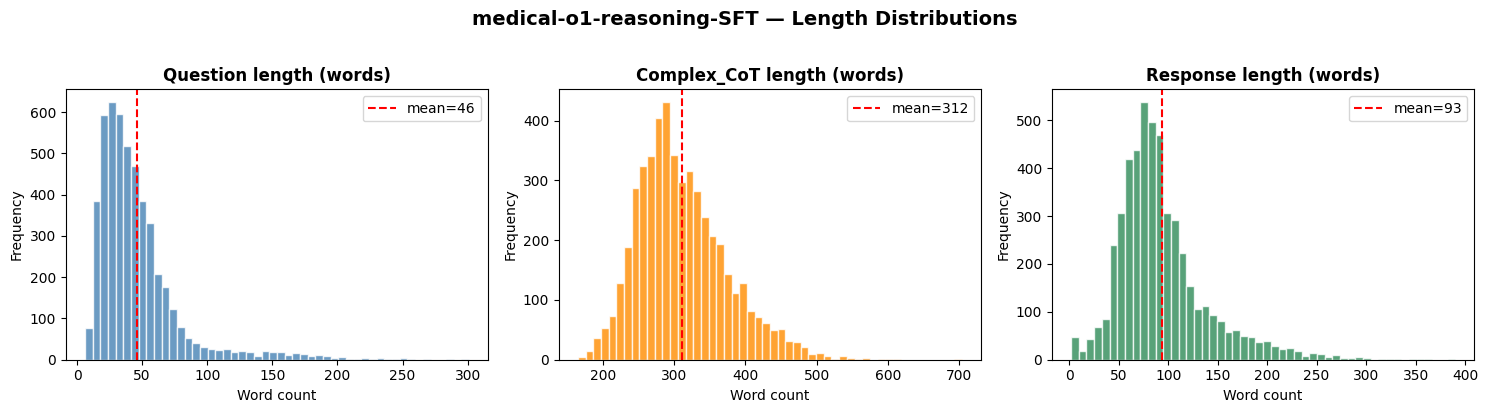

Plot saved: length_distributions.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(
    axes,
    ["Question", "Complex_CoT", "Response"],
    ["steelblue", "darkorange", "seagreen"]
):
    lengths = [len(row[col].split()) for row in subset]
    ax.hist(lengths, bins=50, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(statistics.mean(lengths), color="red", linestyle="--",
               linewidth=1.5, label=f"mean={statistics.mean(lengths):.0f}")
    ax.set_title(f"{col} length (words)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Word count")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("medical-o1-reasoning-SFT — Length Distributions", y=1.02,
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("length_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: length_distributions.png")

## Cell 7 — Chat Template Preview

This is what the model actually sees during training.

In [8]:
from transformers import AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
print(f"Loading tokenizer: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

SYSTEM_MESSAGE = (
    "You are an expert physician with deep knowledge of internal medicine, "
    "cardiology, neurology, and emergency medicine. When presented with a "
    "clinical scenario, you reason through it systematically before providing "
    "your final answer."
)

def format_example(row):
    assistant_content = (
        "Let me reason through this step by step:\n"
        f"{row['Complex_CoT']}\n\n"
        "Final Answer:\n"
        f"{row['Response']}"
    )
    messages = [
        {"role": "system",    "content": SYSTEM_MESSAGE},
        {"role": "user",      "content": row["Question"]},
        {"role": "assistant", "content": assistant_content},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )

# Show first formatted example
sample = subset[0]
formatted = format_example(sample)
print(f"Formatted length: {len(tokenizer.encode(formatted))} tokens\n")
print(formatted[:2000])
print("..." if len(formatted) > 2000 else "")

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0+cu121
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Loading tokenizer: Qwen/Qwen2.5-3B-Instruct...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

d:\pandata\inpanda\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ACER\.cache\huggingface\hub\models--Qwen--Qwen2.5-3B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Formatted length: 866 tokens

<|im_start|>system
You are an expert physician with deep knowledge of internal medicine, cardiology, neurology, and emergency medicine. When presented with a clinical scenario, you reason through it systematically before providing your final answer.<|im_end|>
<|im_start|>user
A 45-year-old man with a history of alcohol use, who has been abstinent for the past 10 years, presents with sudden onset dysarthria, shuffling gait, and intention tremors. Given this clinical presentation and history, what is the most likely diagnosis?<|im_end|>
<|im_start|>assistant
Let me reason through this step by step:
Alright, let’s break this down. We have a 45-year-old man here, who suddenly starts showing some pretty specific symptoms: dysarthria, shuffling gait, and those intention tremors. This suggests something's going wrong with motor control, probably involving the cerebellum or its connections.

Now, what's intriguing is that he's had a history of alcohol use, but he'

## Cell 8 — Token Length Distribution (Post-Formatting)

Computing token lengths for 200-sample subset (full subset takes ~5 min)...


100%|██████████| 200/200 [00:00<00:00, 329.34it/s]



Token length stats (n=200):
  mean   : 676.4
  median : 656
  p95    : 917
  max    : 1111

→ Max seq length of 2048 covers 100.0% of samples


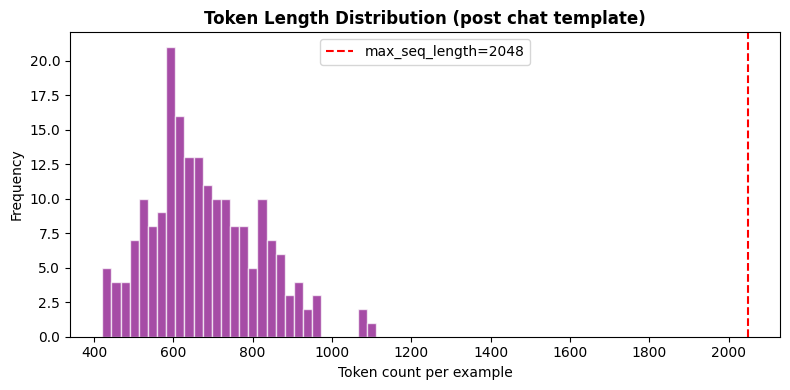

In [9]:
from tqdm import tqdm

print("Computing token lengths for 200-sample subset (full subset takes ~5 min)...")
sample_200 = subset.select(range(200))
token_lengths = []
for row in tqdm(sample_200):
    formatted = format_example(row)
    token_lengths.append(len(tokenizer.encode(formatted)))

s = sorted(token_lengths)
n = len(s)
print(f"\nToken length stats (n={n}):")
print(f"  mean   : {statistics.mean(token_lengths):.1f}")
print(f"  median : {statistics.median(token_lengths):.0f}")
print(f"  p95    : {s[int(0.95*n)]}")
print(f"  max    : {max(token_lengths)}")
print(f"\n→ Max seq length of 2048 covers "
      f"{sum(l <= 2048 for l in token_lengths)/n*100:.1f}% of samples")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(token_lengths, bins=30, color="purple", alpha=0.7, edgecolor="white")
ax.axvline(2048, color="red", linestyle="--", label="max_seq_length=2048")
ax.set_xlabel("Token count per example")
ax.set_ylabel("Frequency")
ax.set_title("Token Length Distribution (post chat template)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Cell 9 — Dataset Summary

In [10]:
print("=" * 60)
print("  DATASET SUMMARY")
print("=" * 60)
print(f"  Source     : {DATASET_NAME}")
print(f"  Full size  : {len(full_ds):,}")
print(f"  Subset     : {NUM_SAMPLES:,} (seed={SEED})")
print(f"  Train      : {len(train_ds):,}")
print(f"  Val        : {len(val_ds):,}")
print(f"  Test       : {len(test_ds):,}")
print(f"  Columns    : {full_ds.column_names}")
print(f"  Model      : {MODEL_NAME}")
print(f"  Max tokens : 2048")
print("=" * 60)
print("\n✅ Dataset looks good! Proceed to Notebook 02 for training.")

  DATASET SUMMARY
  Source     : FreedomIntelligence/medical-o1-reasoning-SFT
  Full size  : 19,704
  Subset     : 5,000 (seed=42)
  Train      : 4,000
  Val        : 500
  Test       : 500
  Columns    : ['Question', 'Complex_CoT', 'Response']
  Model      : Qwen/Qwen2.5-3B-Instruct
  Max tokens : 2048

✅ Dataset looks good! Proceed to Notebook 02 for training.
